## Загружаем нужные нам библиотеки для работы.

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

## Импортируем и читаем наш дадасет

Сложно работать с тем, чего не видел в глаза. Попробуем разобраться о чем идет речь в нашем хранилище

In [2]:
import csv

with open('DailyDelhiClimateTrain.csv', 'r', encoding='utf-8') as f:
    csv_reader = csv.DictReader(f)
    weather_data = list(csv_reader)

for days in weather_data[0:5]:
    print(days)

{'date': '2013-01-01', 'meantemp': '10.0', 'humidity': '84.5', 'wind_speed': '0.0', 'meanpressure': '1015.6666666666666'}
{'date': '2013-01-02', 'meantemp': '7.4', 'humidity': '92.0', 'wind_speed': '2.98', 'meanpressure': '1017.8'}
{'date': '2013-01-03', 'meantemp': '7.166666666666667', 'humidity': '87.0', 'wind_speed': '4.633333333333334', 'meanpressure': '1018.6666666666666'}
{'date': '2013-01-04', 'meantemp': '8.666666666666666', 'humidity': '71.33333333333333', 'wind_speed': '1.2333333333333334', 'meanpressure': '1017.1666666666666'}
{'date': '2013-01-05', 'meantemp': '6.0', 'humidity': '86.83333333333333', 'wind_speed': '3.6999999999999997', 'meanpressure': '1016.5'}


## Подготавливаем данные
Теперь мы имееем представление какие данные мы вообще имеем. Можем заметить, что наш датасет состоит из списка словарей со значениями даты, средней температуры, влажности, скорости ветра и среднего давления, но числа имеют вид строк. Исправим это)))

In [3]:
update_weather_data = []
for day in weather_data:
    converted_day = {'date': day['date'],  # дату оставляем как строку
        'meantemp': float(day['meantemp']),
        'humidity': float(day['humidity']),
        'wind_speed': float(day['wind_speed']),
        'meanpressure': float(day['meanpressure'])}
    update_weather_data.append(converted_day)
#print(update_weather_data)

df = pd.DataFrame(update_weather_data) #для простоты обращения преобразуем данные в таблицу
df['date'] = pd.to_datetime(df['date'])  # преобразуем дату в правильный формат

## Визуализация всех метеопараметров
Тяжело сделать какие-то выводы когда мы имеем просто огромную кучу строчек, поэтому визуализируем данные. Построим графики по всему промежутку времени, это должно показать сезонность и тд. 

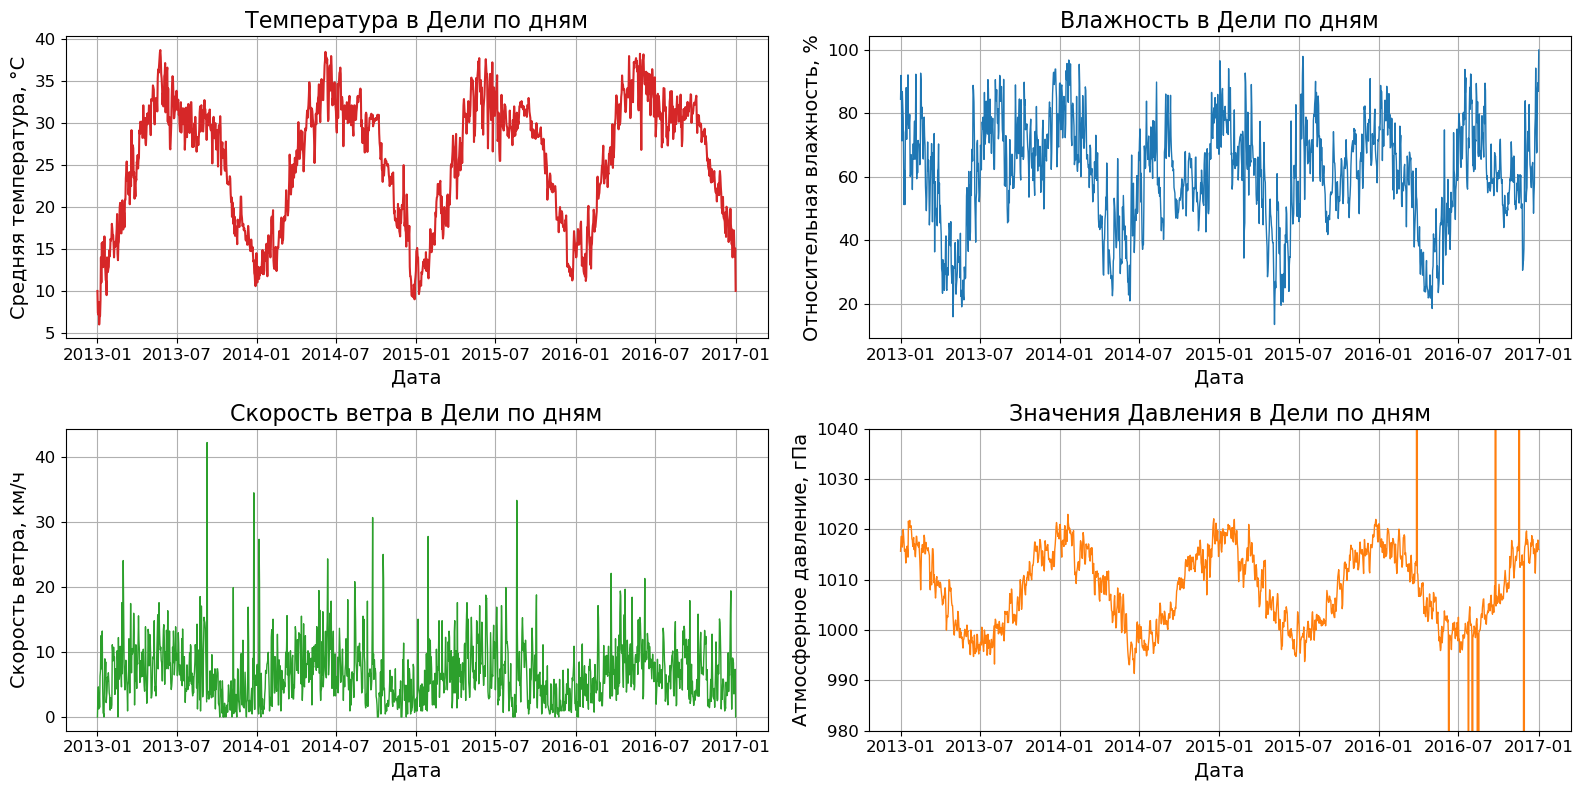

In [4]:
# Создаем сабплот 2x2
fig, ax = plt.subplots(2, 2, figsize=(16, 8))

# График 1: Температура
ax[0, 0].plot(df['date'], df['meantemp'], color='C3')
ax[0, 0].set_ylabel('Средняя температура, °C', fontsize=14)
ax[0, 0].set_xlabel('Дата', fontsize=14)
ax[0, 0].set_title('Температура в Дели по дням', fontsize=16)
ax[0, 0].grid()
ax[0, 0].tick_params(labelsize=12)

# График 2: Влажность
ax[0, 1].plot(df['date'], df['humidity'], color='C0', linewidth=1)
ax[0, 1].set_ylabel('Относительная влажность, %', fontsize=14)
ax[0, 1].set_xlabel('Дата', fontsize=14)
ax[0, 1].set_title('Влажность в Дели по дням', fontsize=16)
ax[0, 1].grid()
ax[0, 1].tick_params(labelsize=12)

# График 3: Скорость ветра
ax[1, 0].plot(df['date'], df['wind_speed'], color='C2', linewidth=1)
ax[1, 0].set_ylabel('Скорость ветра, км/ч', fontsize=14)
ax[1, 0].set_xlabel('Дата', fontsize=14)
ax[1, 0].set_title('Скорость ветра в Дели по дням', fontsize=16)
ax[1, 0].grid()
ax[1, 0].tick_params(labelsize=12)

# График 4: Давление
ax[1, 1].plot(df['date'], df['meanpressure'], color='C1', linewidth=1)
ax[1, 1].set_ylabel('Атмосферное давление, гПа', fontsize=14)
ax[1, 1].set_xlabel('Дата', fontsize=14)
ax[1, 1].set_title('Значения Давления в Дели по дням', fontsize=16)
ax[1, 1].set_ylim(980, 1040) 
ax[1, 1].grid()
ax[1, 1].tick_params(labelsize=12)

plt.tight_layout()

## Что вообще тут происходит???
 - По температуре вообще все очень похоже, сезонность, отчетливо можно поделить каждый год. 
 - Влажность тоже очень сильно похожа на какую-то сезонность, что неудивительно, так как влажность зависит от температуры.
 - Скорость ветра также имеет сезонность и цикличность ,но есть пару аномальных значений (больше 40 км/ч)
 -  Изначально мы подумали, что данные по давлению сломаны, потому что казалось, что это буквально прямая линия с единичными аномальными выбросами(значение в 7000 гПа, население Дели как себя чувствуете?), но мы решили взглянуть на график ближе и обрезать его и наконец увидели ту самую сезонность. В итоге, данные нормальные, но в 2016 году случились какие-то сбои со сбором данных, поэтому он и выдал такие аномальные значени.

## Что от чего зависит вообще?
 Так как все всегда и везде взаимосвязано, мы построили вот такие графики:

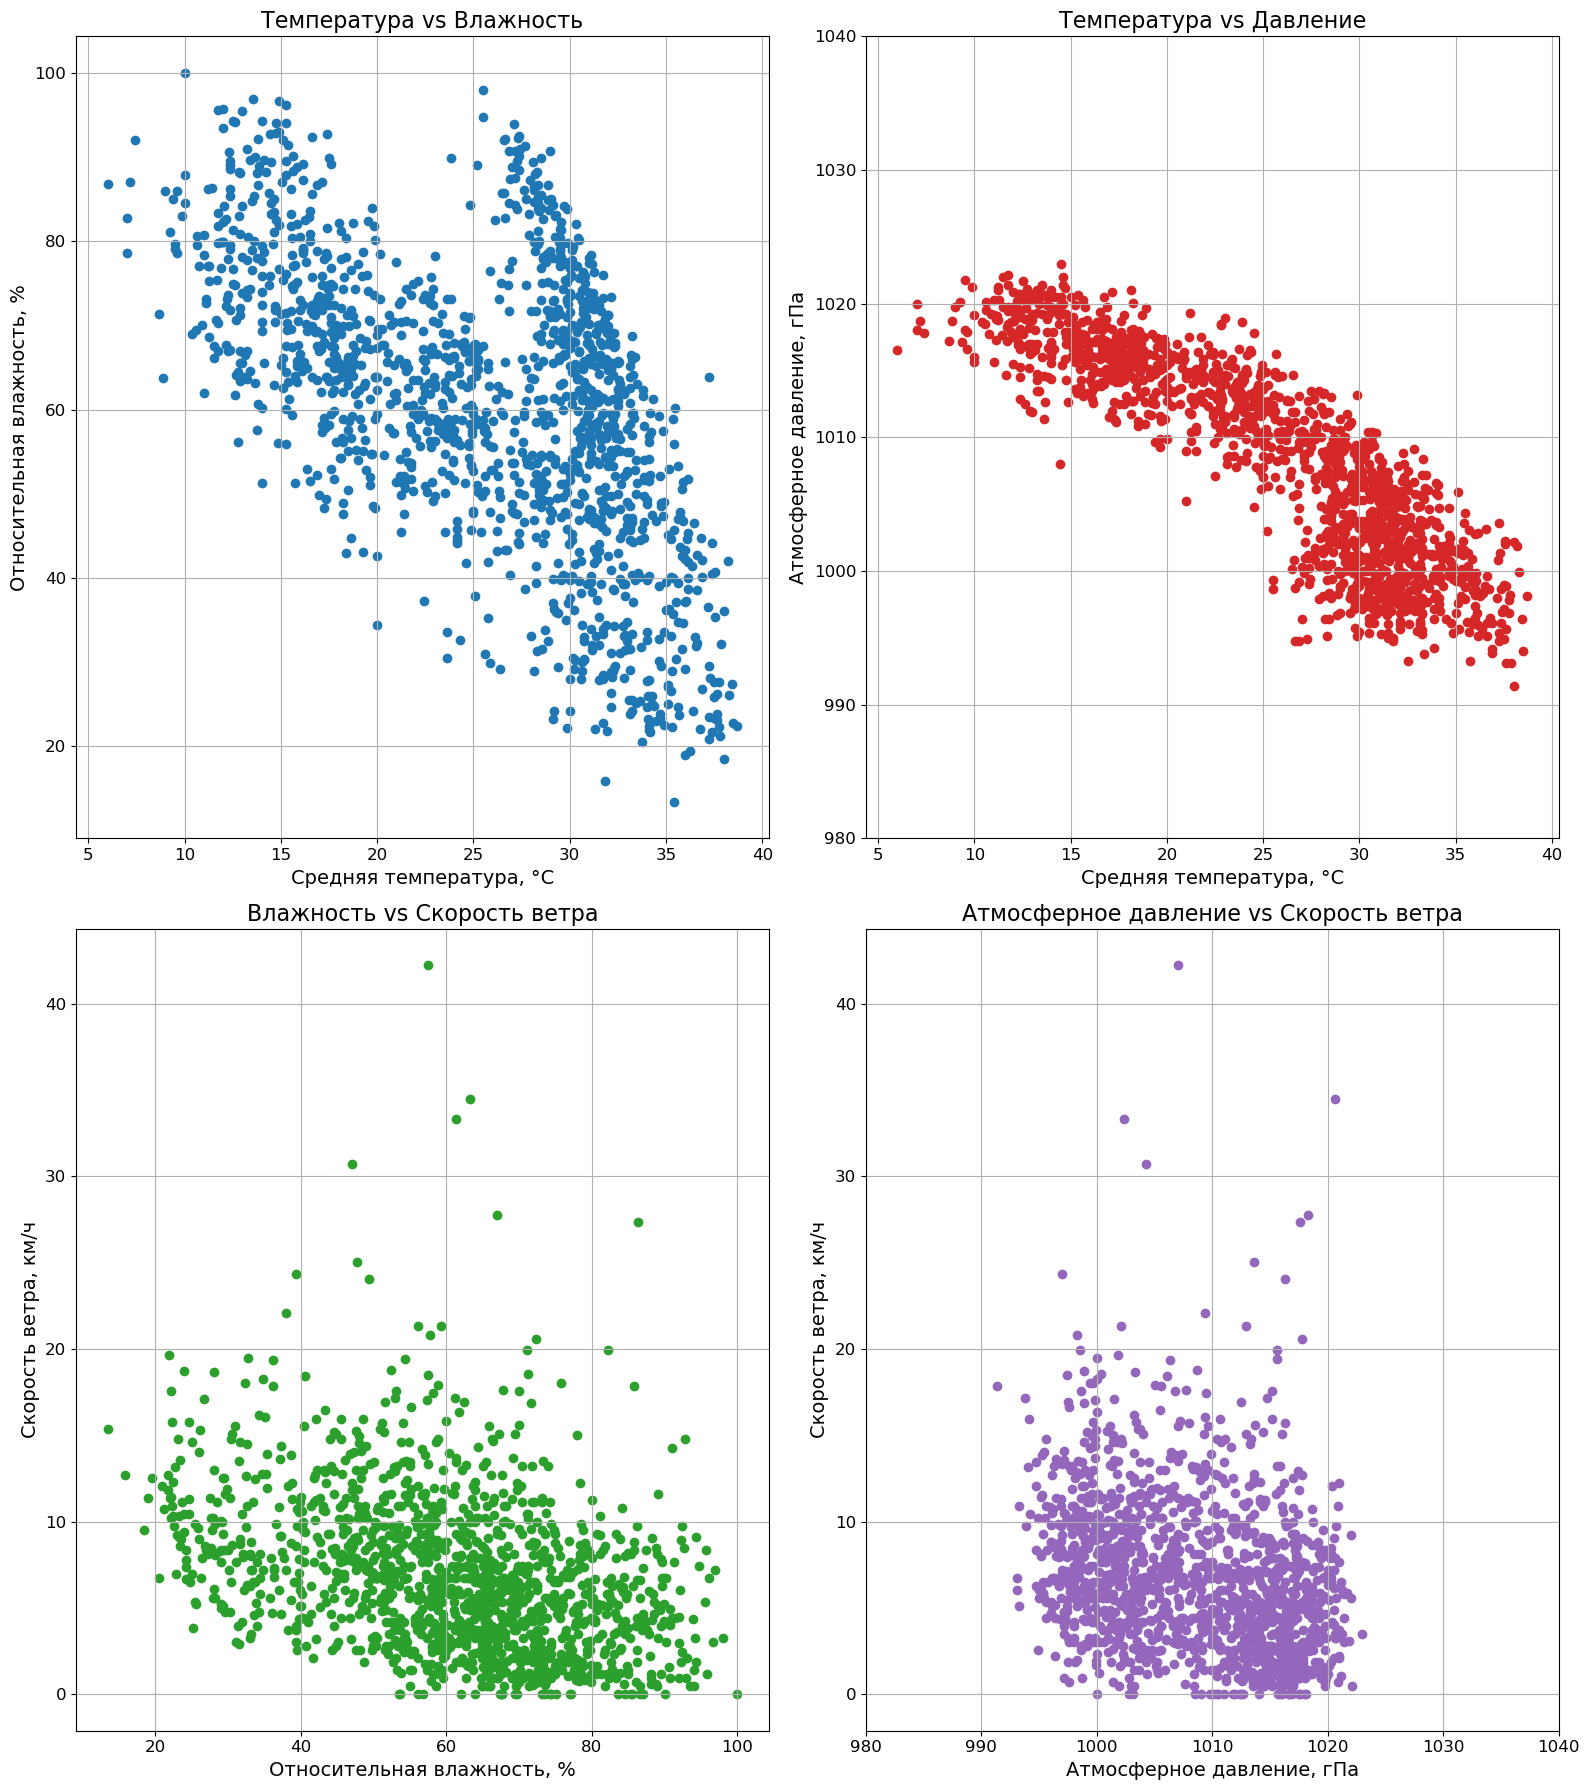

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(16, 18))

# График 1: Температура vs Влажность
ax[0, 0].scatter(df['meantemp'], df['humidity'], color='C0')
ax[0, 0].set_ylabel('Относительная влажность, %', fontsize=14)
ax[0, 0].set_xlabel('Средняя температура, °C', fontsize=14)
ax[0, 0].set_title('Температура vs Влажность', fontsize=16)
ax[0, 0].grid()
ax[0, 0].tick_params(labelsize=12)

# График 2: Температура vs Давление
ax[0, 1].scatter(df['meantemp'], df['meanpressure'], color='C3')
ax[0, 1].set_ylabel('Атмосферное давление, гПа', fontsize=14)
ax[0, 1].set_xlabel('Средняя температура, °C', fontsize=14)
ax[0, 1].set_title('Температура vs Давление', fontsize=16)
ax[0, 1].set_ylim(980, 1040) 
ax[0, 1].grid()
ax[0, 1].tick_params(labelsize=12)

# График 3: Влажность vs Скорость ветра
ax[1, 0].scatter(df['humidity'], df['wind_speed'], color='C2')
ax[1, 0].set_ylabel('Скорость ветра, км/ч', fontsize=14)
ax[1, 0].set_xlabel('Относительная влажность, %', fontsize=14)
ax[1, 0].set_title('Влажность vs Скорость ветра', fontsize=16)
ax[1, 0].grid()
ax[1, 0].tick_params(labelsize=12)

# График 4: Давление vs Скорость ветра
ax[1, 1].scatter(df['meanpressure'], df['wind_speed'], color='C4')
ax[1, 1].set_ylabel('Скорость ветра, км/ч', fontsize=14)
ax[1, 1].set_xlabel('Атмосферное давление, гПа', fontsize=14)
ax[1, 1].set_title('Атмосферное давление vs Скорость ветра', fontsize=16)
ax[1, 1].set_xlim(980, 1040) 
ax[1, 1].grid()
ax[1, 1].tick_params(labelsize=12)

plt.tight_layout()

### Что мы вообще ожидали увидеть здесь?
**Температура vs Влажность** - ожидаем обратную зависимость, поскольку теплый воздух способен содержать больше влаги, что снижает относительную влажность.

**Температура vs Давление** - предполагаем отрицательную корреляцию, так как нагревание воздуха уменьшает его плотность и давление.

**Влажность vs Скорость ветра** - возможна слабая связь, поскольку ветер может приносить воздушные массы с различной влажностью.

**Давление vs Скорость ветра** - ожидаем взаимосвязь, так как ветер возникает из-за разницы градиентов давления.

### Что мы видим?
**Температура vs Влажность** - выглядит правдиво. Однозначный вывод сделать сложно, но в общем - чем выше температура, тем ниже относительная влажность

**Влажность vs Скорость ветра** - нет четкой закономерности в распределении значений. 

**Температура vs Давление** - как и предполагалось, с увеличением температуры давление падает.

**Давление vs Скорость ветра** - так как значения давления у нас нормальные, то вполне логично видеть значения слабых ветров от 0 до 10 км/ч. 


## Поменялись ли значения температуры за 3 года?
Конечно, каких-то сильных изменений распределения температуры и не ожидается, но просто хотелось посмотреть какая тепература была в 2013 и 2016 годах. 

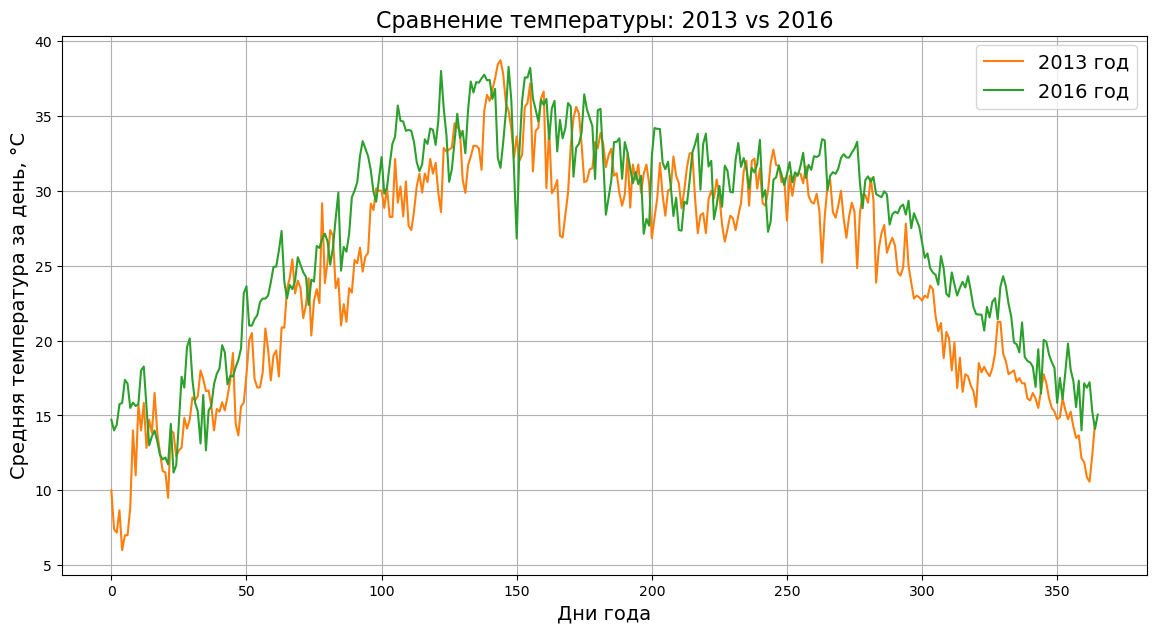

In [9]:
# Создаем два пустых списка -  для температур 2013 и 2016 года
temps_2013 = []
temps_2016 = []

# необычный цикл
#значение дат находятся в формате "Timestamp" и из него нельзя просто так взять первые 4 символа. 
for i in range(len(df)): # Начинаем перебирать все строки в наших данных по порядку
    date = df['date'][i]  # Берем дату из текущей строки под номером i
    year = date.year # Из даты достаем только год 
    temp = float(df['meantemp'][i]) # Берем значение температуры из текущей строки и делаем из него число
    

    if year == 2013: # Проверяем: если год равен 2013
        temps_2013.append(temp) # Тогда добавляем эту температуру в список для 2013 года 
    elif year == 2016: # Иначе проверяем: если год равен 2016 
        temps_2016.append(temp) # Тогда добавляем эту температуру в список для 2016 года

# Строим график
plt.figure(figsize=(14, 7))
plt.plot(temps_2013, color='C1', linewidth=1.5, label='2013 год')
plt.plot(temps_2016, color='C2', linewidth=1.5, label='2016 год')
plt.ylabel('Средняя температура за день, °C', fontsize=14)
plt.xlabel('Дни года', fontsize=14)
plt.title('Сравнение температуры: 2013 vs 2016', fontsize=16)
plt.legend(fontsize=14)
plt.grid()

## Что изменилось?
Если визуально сравнить графики, то можно явно заметить общие тенденции, вау. 
 - В 2016 году было очень резкий спад значений примерно в июне, а в 2013 году он произошел чуть позже.
 - Ноябрь в 2013 году был явно холоднее, чем в 2016 году.
 - Можно предположить, что 2013 был холоднее 2016 (значения 2016 года выше, чем 2013).

## Время подводить итоги


Мы чуть не выкинули данные по давлению, так как сочли их сломанными, поэтому как первый вывод: всегда проверять данные. Иногда они могут казаться сломанными, но это не так.
 - Мы увидели сезонность на всех графиках за несколько лет.
 - Увидели зависимости разных параметров друг от друга. Например, обратную зависимость температуры и относительной влажности.
 - Сравнив данные температур 2013 и 2016 годов, увидели наличие годовых тенденций. Выдвинули предположение о том, что 2013 год был золоднее 2016 года.
